In [5]:
# ma_analysis.py — moving average analysis, week 2 wed
# placeholder prices; replace with CSV read in week 3+

prices = [100.0, 101.5, 102.3, 101.8, 103.1, 104.2, 105.0, 104.8,
          106.1, 107.3, 108.5, 107.9, 109.2, 110.0, 111.3, 110.8,
          112.1, 113.5, 114.2, 115.0]

def moving_average(values, window):
    """compute the simple moving average over `window` periods."""
    result = []
    for i in range(len(values)):
        if i < window - 1:
            result.append(None)
        else:
            total = 0
            for j in range(i - window + 1, i + 1):
                total = total + values[j]
            result.append(total / window)
    return result

sma_5 = moving_average(prices, 5)
sma_10 = moving_average(prices, 10)

for i in range(len(prices)):
    print(f"day {i+1:2d}  price={prices[i]:7.2f}  "
          f"sma5={sma_5[i]!s:>8}  sma10={sma_10[i]!s:>8}")

day  1  price= 100.00  sma5=    None  sma10=    None
day  2  price= 101.50  sma5=    None  sma10=    None
day  3  price= 102.30  sma5=    None  sma10=    None
day  4  price= 101.80  sma5=    None  sma10=    None
day  5  price= 103.10  sma5=101.74000000000001  sma10=    None
day  6  price= 104.20  sma5=102.58000000000001  sma10=    None
day  7  price= 105.00  sma5=  103.28  sma10=    None
day  8  price= 104.80  sma5=  103.78  sma10=    None
day  9  price= 106.10  sma5=104.64000000000001  sma10=    None
day 10  price= 107.30  sma5=105.47999999999999  sma10=103.61000000000001
day 11  price= 108.50  sma5=  106.34  sma10=  104.46
day 12  price= 107.90  sma5=  106.92  sma10=   105.1
day 13  price= 109.20  sma5=   107.8  sma10=105.78999999999999
day 14  price= 110.00  sma5=108.58000000000001  sma10=106.60999999999999
day 15  price= 111.30  sma5=  109.38  sma10=107.42999999999999
day 16  price= 110.80  sma5=  109.84  sma10=  108.09
day 17  price= 112.10  sma5=110.67999999999999  sma10=   108.8

In [6]:
# ma_analysis.py - 移动平均线与买卖信号分析
# 第一部分：价格数据和移动平均线计算

prices = [100.0, 101.5, 102.3, 101.8, 103.1, 104.2, 105.0, 104.8,
          106.1, 107.3, 108.5, 107.9, 109.2, 110.0, 111.3, 110.8,
          112.1, 113.5, 114.2, 115.0]

def moving_average(values, window):
    """计算指定窗口期 window 的简单移动平均线 (SMA)"""
    result = []
    for i in range(len(values)):
        if i < window - 1:
            result.append(None) # 数据不足以计算均线时，填充 None
        else:
            total = 0
            for j in range(i - window + 1, i + 1):
                total = total + values[j]
            result.append(total / window)
    return result

# 第二部分：扩展买卖信号逻辑 (Extend - buy/sell signal logic)

def generate_signals(short_ma, long_ma):
    """根据短期和长期移动平均线的交叉产生 'buy', 'sell' 或 None 信号"""
    signals = []
    
    for i in range(len(short_ma)):
        # 边界检查 1：如果是第一天，或者今天的任何一条均线还没有数据(None)，则无信号
        if i == 0 or short_ma[i] is None or long_ma[i] is None:
            signals.append(None)
            continue
            
        # 获取昨天的均线值
        prev_short = short_ma[i-1]
        prev_long = long_ma[i-1]
        
        # 边界检查 2：如果昨天的任何一条均线还没有数据(None)，说明今天才刚算出第一天的数据，无法形成交叉，无信号
        if prev_short is None or prev_long is None:
            signals.append(None)
            continue
            
        # 核心逻辑：向上交叉产生买入信号 (Upward cross -> buy)
        if prev_short <= prev_long and short_ma[i] > long_ma[i]:
            signals.append("buy")
            
        # 核心逻辑：向下交叉产生卖出信号 (Downward cross -> sell)
        elif prev_short >= prev_long and short_ma[i] < long_ma[i]:
            signals.append("sell")
            
        # 没有发生交叉
        else:
            signals.append(None)
            
    return signals

# --- 运行计算与打印输出 ---

# 计算 5日 和 10日 均线
sma_5 = moving_average(prices, 5)
sma_10 = moving_average(prices, 10)

# 生成买卖信号
signals = generate_signals(sma_5, sma_10)

# 美化打印输出，方便核对逻辑是否正确
print(f"{'天数':>4} | {'价格':>6} | {'5日均线':>8} | {'10日均线':>8} | {'信号':>6}")
print("-" * 50)

for i in range(len(prices)):
    # 格式化价格
    p = f"{prices[i]:.2f}"
    
    # 格式化均线（处理 None 的情况）
    s5_str = f"{sma_5[i]:.2f}" if sma_5[i] is not None else "  None  "
    s10_str = f"{sma_10[i]:.2f}" if sma_10[i] is not None else "  None  "
    
    # 格式化信号（将 None 显示为空白或者减号，更易读）
    sig_str = signals[i] if signals[i] is not None else "-"
    
    # 打印每一行
    print(f"Day {i+1:2d} | {p:>6} | {s5_str:>8} | {s10_str:>8} | {sig_str:>6}")

  天数 |     价格 |     5日均线 |    10日均线 |     信号
--------------------------------------------------
Day  1 | 100.00 |   None   |   None   |      -
Day  2 | 101.50 |   None   |   None   |      -
Day  3 | 102.30 |   None   |   None   |      -
Day  4 | 101.80 |   None   |   None   |      -
Day  5 | 103.10 |   101.74 |   None   |      -
Day  6 | 104.20 |   102.58 |   None   |      -
Day  7 | 105.00 |   103.28 |   None   |      -
Day  8 | 104.80 |   103.78 |   None   |      -
Day  9 | 106.10 |   104.64 |   None   |      -
Day 10 | 107.30 |   105.48 |   103.61 |      -
Day 11 | 108.50 |   106.34 |   104.46 |      -
Day 12 | 107.90 |   106.92 |   105.10 |      -
Day 13 | 109.20 |   107.80 |   105.79 |      -
Day 14 | 110.00 |   108.58 |   106.61 |      -
Day 15 | 111.30 |   109.38 |   107.43 |      -
Day 16 | 110.80 |   109.84 |   108.09 |      -
Day 17 | 112.10 |   110.68 |   108.80 |      -
Day 18 | 113.50 |   111.54 |   109.67 |      -
Day 19 | 114.20 |   112.38 |   110.48 |      -
Day 20 | 11

In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


✅ 图表已保存至: sample_output.png


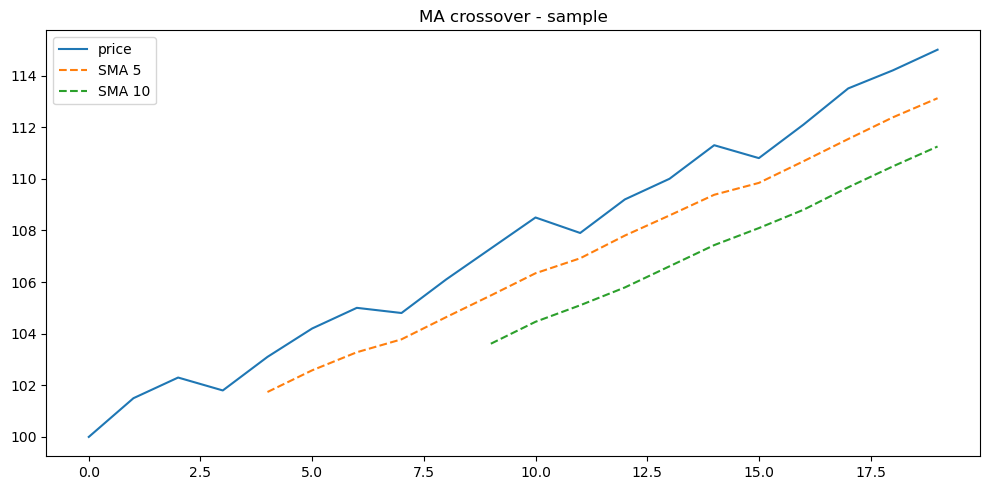

In [8]:
# 第三部分：使用 Matplotlib 进行数据可视化 (Day 5 任务)
# =====================================================================

# 导入绘图库 (如果 Jupyter 报错说找不到库，请先在一个新单元格运行 %pip install matplotlib)
import matplotlib.pyplot as plt

def plot_ma(prices, sma_5, sma_10, signals, path="sample_output.png"):
    """
    绘制价格曲线、双均线，并标注买卖信号。
    最后将图表保存为本地图片。
    """
    # 创建一个宽10、高5的画板
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 1. 绘制基础折线
    # 绘制基础价格线 (实线)
    ax.plot(prices, label="price", linewidth=1.5)
    # 绘制5日均线 (虚线)
    ax.plot(sma_5, label="SMA 5", linestyle="--")
    # 绘制10日均线 (虚线)
    ax.plot(sma_10, label="SMA 10", linestyle="--")
    
    # 2. 绘制买卖信号点
    # 使用 enumerate 遍历信号列表，i 是天数(横坐标)，s 是信号值(buy/sell/None)
    for i, s in enumerate(signals):
        if s == "buy":
            # 绘制绿色向上的三角形标记 (marker="^")，位于当天的价格点上
            ax.scatter(i, prices[i], marker="^", s=90, color="green", zorder=5)
        elif s == "sell":
            # 绘制红色向下的三角形标记 (marker="v")
            ax.scatter(i, prices[i], marker="v", s=90, color="red", zorder=5)
            
    # 3. 设置图表属性
    # 设置图表标题
    ax.set_title("MA crossover - sample")
    # 显示图例 (左上角解释线条颜色的框)
    ax.legend()
    # 自动调整布局，防止标签被截断
    fig.tight_layout()
    
    # 4. 保存和展示
    # 将图表保存为项目目录下的图片文件 (用于 README)
    fig.savefig(path, dpi=120)
    print(f"✅ 图表已保存至: {path}")
    
    # 在 Jupyter 界面中直接显示图表
    plt.show()

# 执行绘图函数
plot_ma(prices, sma_5, sma_10, signals)